Loading ERA5MultiData...
Loading ERA5 data from C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc
Applying slicing: {'valid_time': slice(0, 10, None), 'pressure_level': slice(0, 5, None), 'latitude': slice(0, 50, None), 'longitude': slice(0, 100, None)}
Coordinate ranges:
  valid_time: shape=(10,), range=[1664323200.00, 1664355584.00]
  pressure_level: shape=(5,), range=[750.00, 850.00]
  latitude: shape=(50,), range=[77.75, 90.00]
  longitude: shape=(100,), range=[0.00, 24.75]
Preloading data into memory...
  Loading u...
    Memory usage: 0.00 GB
  Loading v...
    Memory usage: 0.00 GB
  Loading w...
    Memory usage: 0.00 GB
  Loading z...
    Memory usage: 0.00 GB
Successfully loaded 4 variables:
   u: (10, 5, 50, 100)
   v: (10, 5, 50, 100)
   w: (10, 5, 50, 100)
   z: (10, 5, 50, 100)
 Data loaded!


 ERA5MultiDataset Test Suite
Test 1: Dataset Initialization

 Dataset created successfully!
  Number of samples: 1000
  Variables: ['u', 'v', 'w', 'z']
  Indices shape: (

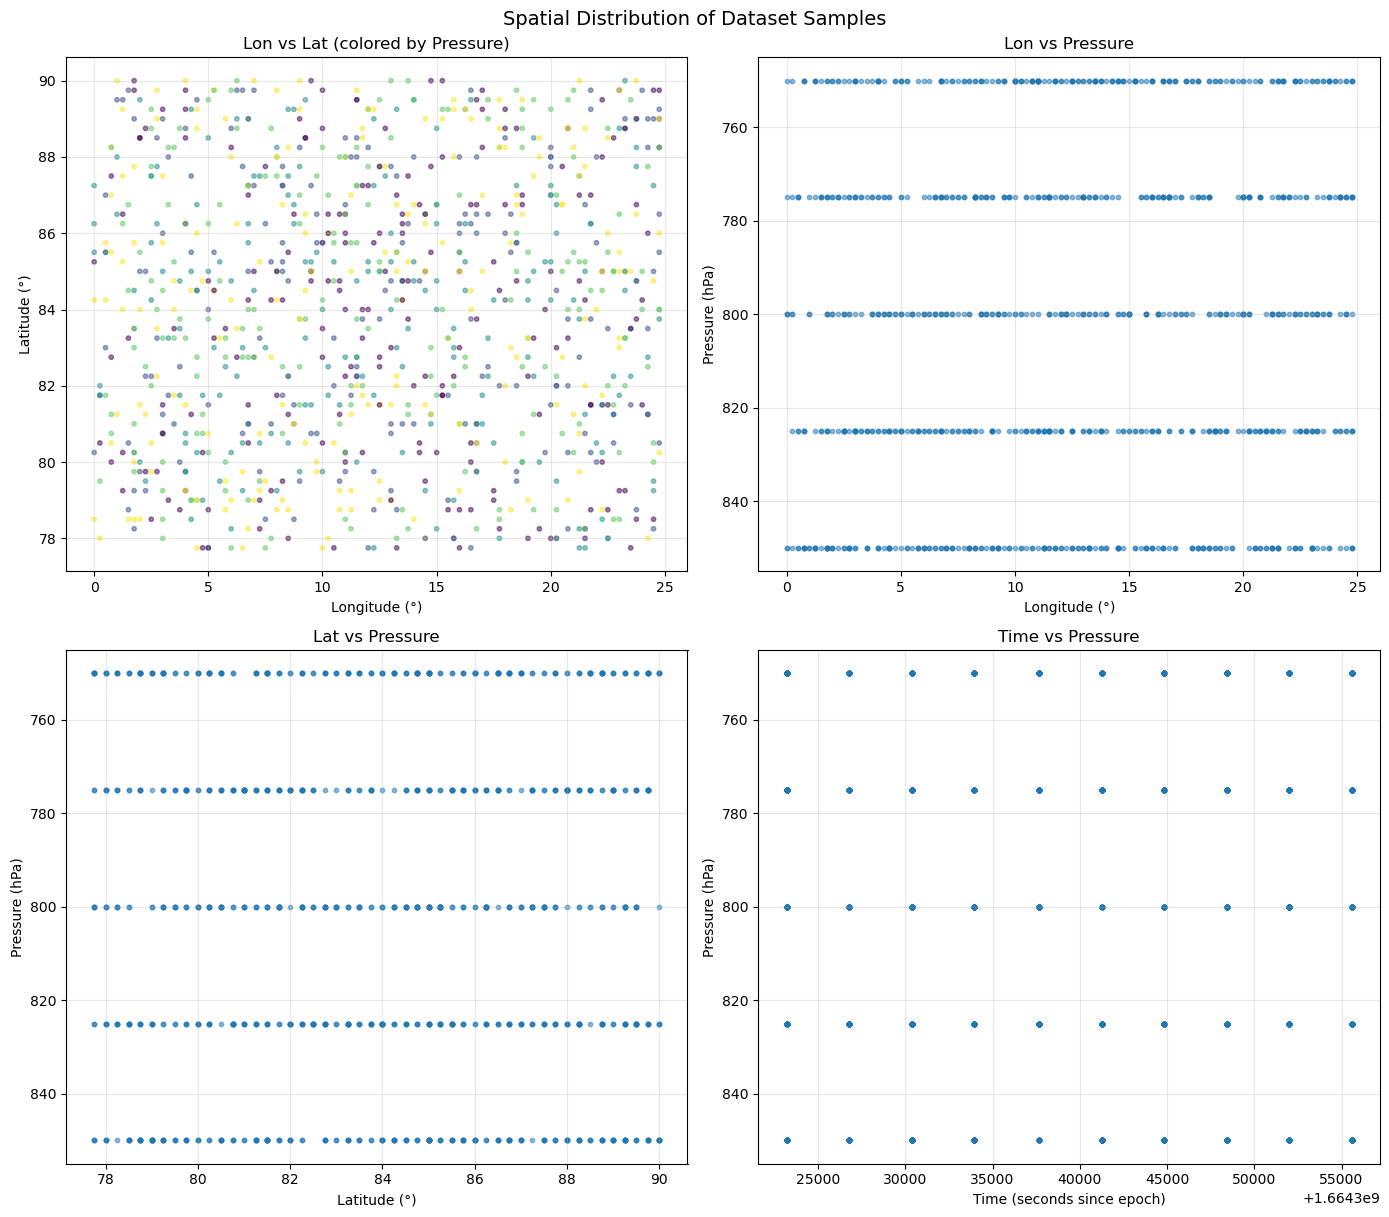


 Spatial distribution visualized!

Test 8: Visualize Value Distributions



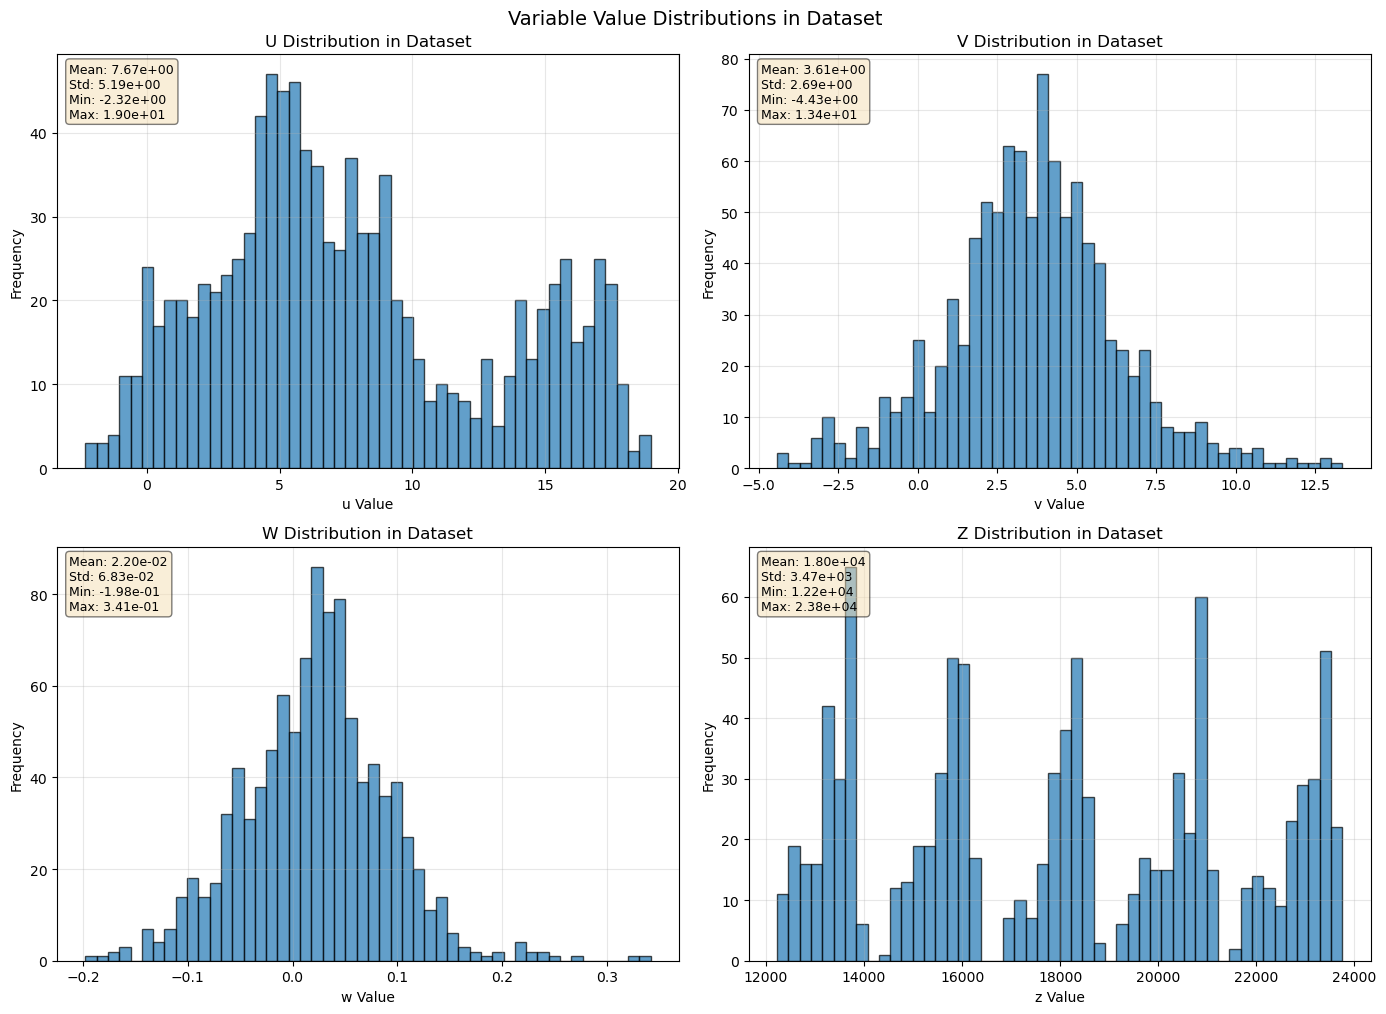


 Value distributions visualized!

Test 9: Batched Access Performance

  Testing different batch sizes:
    Batch size   1: 0.030s (32848 samples/sec)
    Batch size  16: 0.013s (78428 samples/sec)
    Batch size  32: 0.012s (83204 samples/sec)
    Batch size  64: 0.011s (89442 samples/sec)
    Batch size 128: 0.012s (86056 samples/sec)

 Performance test complete!

Test 10: 3D Scatter of Dataset Samples

  Plotting 1000 samples in 3D


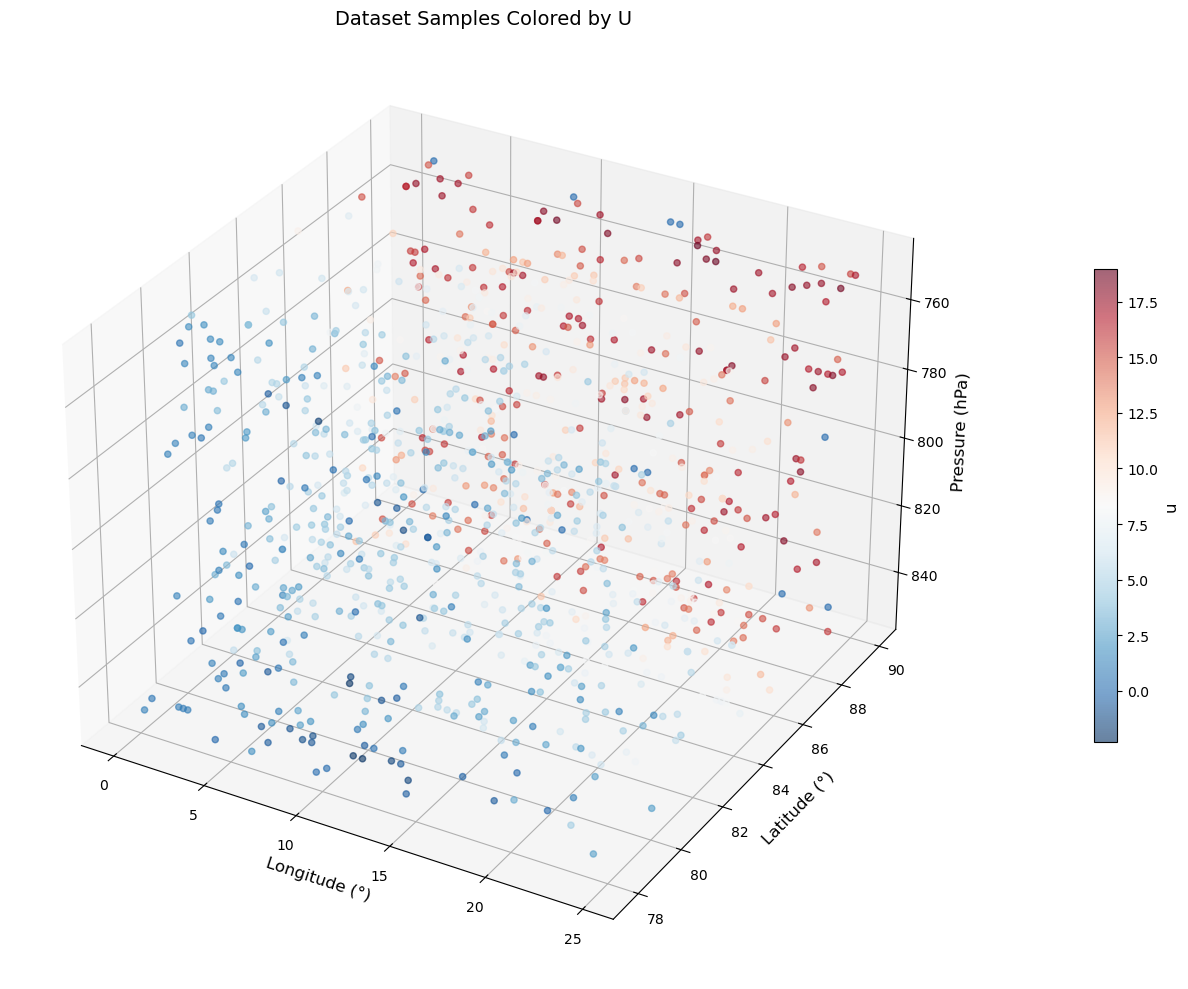


 3D scatter plot created!

All Tests Completed Successfully!


In [2]:
# Test Notebook for ERA5MultiDataset

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

import sys
sys.path.insert(0, r'C:\Users\micke\OneDrive - University of Toronto\geo_lab')
from geolab.data.dataset import ERA5MultiData, ERA5MultiDataset

# ============================================================================
# CONFIGURATION - UPDATE THESE
# ============================================================================
DATA_DIR = Path(r"C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc") # UPDATE THIS
VARIABLES = ['u', 'v', 'w', 'z']  # UPDATE WITH YOUR VARIABLES

# Load ERA5MultiData for testing
print("Loading ERA5MultiData...")
era5_data = ERA5MultiData(
    data_dir=DATA_DIR,
    variables=VARIABLES,
    time_idx_range=[0, 10],
    pressure_idx_range=[0, 5],
    latitude_idx_range=[0, 50],
    longitude_idx_range=[0, 100],
    preload=True
)
print(" Data loaded!\n")


# ============================================================================
# Helper: Create Sample Indices
# ============================================================================
def create_sample_indices(data, n_samples=1000, seed=42):
    """Create random 4D indices for sampling."""
    np.random.seed(seed)

    indices = np.array([
        np.random.randint(0, data.num_times, n_samples),
        np.random.randint(0, data.num_pressure_levels, n_samples),
        np.random.randint(0, data.num_latitudes, n_samples),
        np.random.randint(0, data.num_longitudes, n_samples)
    ]).T  # Shape: (n_samples, 4)

    return indices


# Helper: Create Dummy Statistics
def create_dummy_statistics(data):
    """Create dummy statistics dict (not used by dataset but kept for compatibility)."""
    stats = {}
    for var in VARIABLES:
        var_data = data.data_arrays[var]
        stats[var] = {
            'min': float(var_data.min()),
            'max': float(var_data.max()),
            'mean': float(var_data.mean()),
            'std': float(var_data.std())
        }

    # Add coordinate stats
    stats['valid_time'] = {
        'min': float(data.times.min()),
        'max': float(data.times.max())
    }
    stats['pressure_level'] = {
        'min': float(data.pressure_levels.min()),
        'max': float(data.pressure_levels.max())
    }
    stats['latitude'] = {
        'min': float(data.latitudes.min()),
        'max': float(data.latitudes.max())
    }
    stats['longitude'] = {
        'min': float(data.longitudes.min()),
        'max': float(data.longitudes.max())
    }

    return stats


# ============================================================================
# Test 1: Basic Dataset Initialization
# ============================================================================
def test_dataset_init():
    """Test basic dataset initialization."""
    print("=" * 60)
    print("Test 1: Dataset Initialization")
    print("=" * 60)

    # Create indices
    n_samples = 1000
    indices = create_sample_indices(era5_data, n_samples)
    stats = create_dummy_statistics(era5_data)

    # Create dataset
    dataset = ERA5MultiDataset(
        data=era5_data,
        indices=indices,
        statistics=stats,
        variables=VARIABLES
    )

    print(f"\n Dataset created successfully!")
    print(f"  Number of samples: {len(dataset)}")
    print(f"  Variables: {dataset.variables}")
    print(f"  Indices shape: {dataset.indices.shape}")

    return dataset, indices, stats


# ============================================================================
# Test 2: Test __len__ Method
# ============================================================================
def test_dataset_length(dataset):
    """Test dataset length."""
    print("\n" + "=" * 60)
    print("Test 2: Dataset Length")
    print("=" * 60)

    length = len(dataset)
    expected_length = len(dataset.indices)

    print(f"\n  Dataset length: {length}")
    print(f"  Expected length: {expected_length}")

    assert length == expected_length, "Length mismatch!"
    print(f"\n Length test passed!")


# ============================================================================
# Test 3: Test __getitem__ Method
# ============================================================================
def test_dataset_getitem(dataset):
    """Test getting individual samples."""
    print("\n" + "=" * 60)
    print("Test 3: Get Individual Samples")
    print("=" * 60)

    # Get first sample
    sample = dataset[0]

    print(f"\n  Sample keys: {list(sample.keys())}")
    print(f"  Coords shape: {sample['coords'].shape}")
    print(f"  Coords dtype: {sample['coords'].dtype}")
    print(f"  Values shape: {sample['values'].shape}")
    print(f"  Values dtype: {sample['values'].dtype}")

    print(f"\n  Sample 0 coordinates:")
    print(f"    Time: {sample['coords'][0].item():.2e}")
    print(f"    Pressure: {sample['coords'][1].item():.2f} hPa")
    print(f"    Latitude: {sample['coords'][2].item():.2f}°")
    print(f"    Longitude: {sample['coords'][3].item():.2f}°")

    print(f"\n  Sample 0 values:")
    for i, var in enumerate(VARIABLES):
        print(f"    {var}: {sample['values'][i].item():.4e}")

    # Test multiple samples
    print(f"\n  Testing samples 0-9:")
    for idx in range(min(10, len(dataset))):
        sample = dataset[idx]
        assert sample['coords'].shape == (4,), f"Coords shape mismatch at idx {idx}"
        assert sample['values'].shape == (len(VARIABLES),), f"Values shape mismatch at idx {idx}"
        assert sample['coords'].dtype == torch.float32, f"Coords dtype mismatch at idx {idx}"
        assert sample['values'].dtype == torch.float32, f"Values dtype mismatch at idx {idx}"

    print(f"\n GetItem test passed!")

    return sample


# ============================================================================
# Test 4: Verify Coordinate Values Match Data
# ============================================================================
def test_coordinate_consistency(dataset):
    """Verify that dataset coordinates match the underlying data."""
    print("\n" + "=" * 60)
    print("Test 4: Coordinate Consistency")
    print("=" * 60)

    # Get sample from dataset
    idx = 42
    sample = dataset[idx]

    # Get indices
    time_idx, pressure_idx, lat_idx, lon_idx = dataset.indices[idx]

    # Get coordinates directly from ERA5MultiData
    coords_direct = era5_data.get_coords_at_index(
        time_idx, pressure_idx, lat_idx, lon_idx
    )

    # Compare
    coords_dataset = sample['coords'].numpy()

    print(f"\n  Sample index: {idx}")
    print(f"  4D indices: [{time_idx}, {pressure_idx}, {lat_idx}, {lon_idx}]")
    print(f"\n  Coordinates from dataset:")
    print(f"    {coords_dataset}")
    print(f"  Coordinates from data:")
    print(f"    {coords_direct}")
    print(f"  Difference:")
    print(f"    {np.abs(coords_dataset - coords_direct)}")

    assert np.allclose(coords_dataset, coords_direct), "Coordinate mismatch!"

    print(f"\n Coordinate consistency verified!")


# ============================================================================
# Test 5: Verify Variable Values Match Data
# ============================================================================
def test_value_consistency(dataset):
    """Verify that dataset values match the underlying data."""
    print("\n" + "=" * 60)
    print("Test 5: Value Consistency")
    print("=" * 60)

    # Test multiple samples
    n_test = 10
    print(f"\n  Testing {n_test} samples...")

    for idx in range(n_test):
        sample = dataset[idx]
        time_idx, pressure_idx, lat_idx, lon_idx = dataset.indices[idx]

        # Get values directly from ERA5MultiData
        for var_idx, var in enumerate(VARIABLES):
            value_direct = era5_data.get_values_at_index(
                var, time_idx, pressure_idx, lat_idx, lon_idx
            )
            value_dataset = sample['values'][var_idx].item()

            diff = abs(value_dataset - value_direct)
            assert diff < 1e-6, f"Value mismatch for {var} at idx {idx}: {diff}"

    print(f"\n Value consistency verified for {n_test} samples!")


# ============================================================================
# Test 6: Test with DataLoader
# ============================================================================
def test_with_dataloader(dataset):
    """Test dataset with PyTorch DataLoader."""
    print("\n" + "=" * 60)
    print("Test 6: DataLoader Integration")
    print("=" * 60)

    batch_size = 32
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0  # Set to 0 for Windows compatibility
    )

    print(f"\n  DataLoader created:")
    print(f"    Batch size: {batch_size}")
    print(f"    Number of batches: {len(dataloader)}")

    # Get first batch
    batch = next(iter(dataloader))

    print(f"\n  First batch:")
    print(f"    Coords shape: {batch['coords'].shape}")
    print(f"    Values shape: {batch['values'].shape}")

    assert batch['coords'].shape == (batch_size, 4), "Batch coords shape mismatch"
    assert batch['values'].shape == (batch_size, len(VARIABLES)), "Batch values shape mismatch"

    # Test iteration
    print(f"\n  Testing full iteration...")
    total_samples = 0
    for batch_idx, batch in enumerate(dataloader):
        total_samples += batch['coords'].shape[0]
        if batch_idx < 3:  # Print first 3 batches
            print(f"    Batch {batch_idx}: {batch['coords'].shape[0]} samples")

    print(f"\n  Total samples processed: {total_samples}")
    assert total_samples == len(dataset), "Sample count mismatch!"

    print(f"\n DataLoader test passed!")

    return dataloader


# ============================================================================
# Test 7: Visualize Spatial Distribution of Samples
# ============================================================================
def test_visualize_spatial_distribution(dataset):
    """Visualize spatial distribution of sampled points."""
    print("\n" + "=" * 60)
    print("Test 7: Visualize Spatial Distribution")
    print("=" * 60)

    # Get all coordinates
    n_vis = min(1000, len(dataset))
    coords_list = []

    for idx in range(n_vis):
        sample = dataset[idx]
        coords_list.append(sample['coords'].numpy())

    coords_array = np.array(coords_list)  # Shape: (n_vis, 4)

    print(f"\n  Visualizing {n_vis} samples")

    # Create 2x2 subplot
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Lon vs Lat
    axes[0, 0].scatter(coords_array[:, 3], coords_array[:, 2],
                       alpha=0.5, s=10, c=coords_array[:, 1], cmap='viridis')
    axes[0, 0].set_xlabel('Longitude (°)')
    axes[0, 0].set_ylabel('Latitude (°)')
    axes[0, 0].set_title('Lon vs Lat (colored by Pressure)')
    axes[0, 0].grid(True, alpha=0.3)

    # Lon vs Pressure
    axes[0, 1].scatter(coords_array[:, 3], coords_array[:, 1],
                       alpha=0.5, s=10)
    axes[0, 1].set_xlabel('Longitude (°)')
    axes[0, 1].set_ylabel('Pressure (hPa)')
    axes[0, 1].set_title('Lon vs Pressure')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3)

    # Lat vs Pressure
    axes[1, 0].scatter(coords_array[:, 2], coords_array[:, 1],
                       alpha=0.5, s=10)
    axes[1, 0].set_xlabel('Latitude (°)')
    axes[1, 0].set_ylabel('Pressure (hPa)')
    axes[1, 0].set_title('Lat vs Pressure')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(True, alpha=0.3)

    # Time vs Pressure
    axes[1, 1].scatter(coords_array[:, 0], coords_array[:, 1],
                       alpha=0.5, s=10)
    axes[1, 1].set_xlabel('Time (seconds since epoch)')
    axes[1, 1].set_ylabel('Pressure (hPa)')
    axes[1, 1].set_title('Time vs Pressure')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Spatial Distribution of Dataset Samples', y=1.01, fontsize=14)
    plt.show()

    print(f"\n Spatial distribution visualized!")


# ============================================================================
# Test 8: Visualize Variable Value Distributions
# ============================================================================
def test_visualize_value_distributions(dataset):
    """Visualize distributions of variable values in dataset."""
    print("\n" + "=" * 60)
    print("Test 8: Visualize Value Distributions")
    print("=" * 60)

    # Collect values
    n_vis = min(5000, len(dataset))
    values_dict = {var: [] for var in VARIABLES}

    print(f"\n  Collecting {n_vis} samples...")
    for idx in range(n_vis):
        sample = dataset[idx]
        for var_idx, var in enumerate(VARIABLES):
            values_dict[var].append(sample['values'][var_idx].item())

    # Convert to arrays
    for var in VARIABLES:
        values_dict[var] = np.array(values_dict[var])

    # Plot
    n_vars = len(VARIABLES)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, var in enumerate(VARIABLES[:4]):
        values = values_dict[var]

        axes[idx].hist(values, bins=50, alpha=0.7, edgecolor='black')
        axes[idx].set_xlabel(f'{var} Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{var.upper()} Distribution in Dataset')
        axes[idx].grid(True, alpha=0.3)

        # Add stats
        stats_text = f'Mean: {values.mean():.2e}\nStd: {values.std():.2e}\nMin: {values.min():.2e}\nMax: {values.max():.2e}'
        axes[idx].text(0.02, 0.98, stats_text,
                      transform=axes[idx].transAxes,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)

    plt.tight_layout()
    plt.suptitle('Variable Value Distributions in Dataset', y=1.01, fontsize=14)
    plt.show()

    print(f"\n Value distributions visualized!")


# ============================================================================
# Test 9: Test Batched Access Performance
# ============================================================================
def test_batched_access_performance(dataset):
    """Test performance of batched data access."""
    print("\n" + "=" * 60)
    print("Test 9: Batched Access Performance")
    print("=" * 60)

    import time

    batch_sizes = [1, 16, 32, 64, 128]

    print(f"\n  Testing different batch sizes:")
    for batch_size in batch_sizes:
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        # Time one epoch
        start = time.time()
        for batch in dataloader:
            pass  # Just iterate
        elapsed = time.time() - start

        samples_per_sec = len(dataset) / elapsed

        print(f"    Batch size {batch_size:3d}: {elapsed:.3f}s ({samples_per_sec:.0f} samples/sec)")

    print(f"\n Performance test complete!")


# ============================================================================
# Test 10: 3D Scatter of Dataset Samples
# ============================================================================
def test_3d_scatter_samples(dataset):
    """Create 3D scatter plot of dataset samples."""
    print("\n" + "=" * 60)
    print("Test 10: 3D Scatter of Dataset Samples")
    print("=" * 60)

    # Get samples
    n_vis = min(2000, len(dataset))
    coords_list = []
    values_list = []

    for idx in range(n_vis):
        sample = dataset[idx]
        coords_list.append(sample['coords'].numpy())
        values_list.append(sample['values'][0].item())  # First variable

    coords_array = np.array(coords_list)
    values_array = np.array(values_list)

    print(f"\n  Plotting {n_vis} samples in 3D")

    # Plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        coords_array[:, 3],  # longitude
        coords_array[:, 2],  # latitude
        coords_array[:, 1],  # pressure
        c=values_array,
        cmap='RdBu_r',
        alpha=0.6,
        s=20
    )

    ax.invert_zaxis()
    ax.set_xlabel('Longitude (°)', fontsize=12)
    ax.set_ylabel('Latitude (°)', fontsize=12)
    ax.set_zlabel('Pressure (hPa)', fontsize=12)
    ax.set_title(f'Dataset Samples Colored by {VARIABLES[0].upper()}', fontsize=14)

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label(f'{VARIABLES[0]}', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n 3D scatter plot created!")


# ============================================================================
# Run All Tests
# ============================================================================
def run_all_tests():
    """Run all ERA5MultiDataset tests."""
    print("\n" + "=" * 70)
    print(" ERA5MultiDataset Test Suite")
    print("=" * 70)

    # Test 1: Initialize dataset
    dataset, indices, stats = test_dataset_init()

    # Test 2: Length
    test_dataset_length(dataset)

    # Test 3: GetItem
    sample = test_dataset_getitem(dataset)

    # Test 4-5: Consistency
    test_coordinate_consistency(dataset)
    test_value_consistency(dataset)

    # Test 6: DataLoader
    dataloader = test_with_dataloader(dataset)

    # Test 7-8: Visualizations
    test_visualize_spatial_distribution(dataset)
    test_visualize_value_distributions(dataset)

    # Test 9: Performance
    test_batched_access_performance(dataset)

    # Test 10: 3D scatter
    test_3d_scatter_samples(dataset)

    print("\n" + "=" * 70)
    print("All Tests Completed Successfully!")
    print("=" * 70)

    return {
        'dataset': dataset,
        'dataloader': dataloader,
        'indices': indices,
        'stats': stats
    }


# ============================================================================
# Run Tests
# ============================================================================
if __name__ == "__main__":
    results = run_all_tests()